# 1. Dataset Loading and Verification

In this section, we:

- Import the required libraries
- Load training, validation, and test datasets
- Verify image-label consistency
- Check for missing or corrupted images
- Analyze image dimensions and formats
- Identify duplicate entries

This step is important to ensure that the dataset is clean and reliable before performing exploratory data analysis and model training.

In [1]:
# Install required packages

!pip install pandas numpy matplotlib seaborn pillow tqdm scipy

## 1.1 Import Libraries

The following libraries are used for:

- data handling,
- image processing,
- visualization,
- and dataset verification.

In [2]:
# Import required packages

import os
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split

## 1.2 Define Dataset Paths

We define the paths for the training, validation, and testing datasets.

In [3]:
# Root dataset folder
DATASET_PATH = Path("dataset")

# Train paths
TRAIN_PATH = DATASET_PATH / "train"

# Validation paths
VALIDATE_PATH = DATASET_PATH / "valid"

# Test paths
TEST_PATH = DATASET_PATH / "test"

## 1.3 Load Label Files

Each dataset split contains a CSV file with image labels.

We load the CSV files into pandas DataFrames for analysis.

In [4]:
# Load CSV label files

train_df = pd.read_csv(TRAIN_PATH / "_classes.csv")
validate_df = pd.read_csv(VALIDATE_PATH / "_classes.csv")
test_df = pd.read_csv(TEST_PATH / "_classes.csv")

## 1.4 Preview Dataset

We inspect the first few rows of each dataset to understand the structure of the labels.

In [5]:
print("Train Dataset")
display(train_df.head())

print("\nValidation Dataset")
display(validate_df.head())

print("\nTest Dataset")
display(test_df.head())

Train Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,thinkwithgoogle_com_png.rf.0e3CasnPbMEGQSO8oMH...,1,1,1,0,1,0,1,1
1,urlzs_com_png.rf.0ea1b14c371dff348e9bba2948d8e...,1,0,0,0,1,0,0,1
2,amazon_com_png.rf.0oB8qzojBS2Tklffo69l.jpg,1,1,1,1,1,0,1,1
3,asahi_com_png.rf.120e05a147314b2805e7bad82dafc...,1,0,1,1,1,0,1,1
4,buymeacoffee_com_png.rf.0vBkaAYTkLI6YlTz5Gqu.jpg,1,1,1,0,1,0,0,1



Validation Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,tw_bid_yahoo_com_png.rf.00142efb44982bd766357c...,1,1,1,0,1,0,1,1
1,heavy_com_png.rf.02292a8559ef48759cdd54c775747...,1,1,1,0,1,0,1,1
2,buildyourfuture_withgoogle_com_png.rf.025d26dc...,1,0,1,0,1,0,1,1
3,crunchbase_com_png.rf.0269a6590355e6a198be21af...,0,0,1,0,1,0,1,1
4,radiolab_org_png.rf.045797115c9c28897a3ef9a34f...,1,0,1,1,1,0,1,1



Test Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,bbc_com_png.rf.01759781597857d451c44c7560e4e0b...,1,1,1,0,1,0,0,1
1,europarl_europa_eu_png.rf.0437dcc6989de06ee86c...,1,1,1,0,0,0,0,1
2,groups_yahoo_com_png.rf.06f3a1e8a3284cca2b1231...,1,1,1,0,1,0,1,1
3,wikihow_com_png.rf.06129667a4177043698b33e20e2...,1,1,1,0,1,0,1,1
4,shop_gopro_com_png.rf.08dff9eeeb81fc95d8f85eb4...,1,0,1,0,1,0,1,1


## 1.5 Check Dataset Shapes

We check the number of samples and label columns in each dataset split.

In [6]:
print("Train Shape:", train_df.shape)
print("Validation Shape:", validate_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1688, 9)
Validation Shape: (482, 9)
Test Shape: (242, 9)


## 1.6 Verify Missing Values

We check whether the dataset contains missing values in any column.

In [7]:
print("Missing values in training set:")
display(train_df.isnull().sum())

print("\nMissing values in validation set:")
display(validate_df.isnull().sum())

print("\nMissing values in test set:")
display(test_df.isnull().sum())

Missing values in training set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in validation set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in test set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64

## 1.7 Check Duplicate Entries

Duplicate entries may negatively affect model training and evaluation.

We check for duplicate rows in each dataset.

In [8]:
print("Duplicate rows in training set:", train_df.duplicated().sum())
print("Duplicate rows in validation set:", validate_df.duplicated().sum())
print("Duplicate rows in test set:", test_df.duplicated().sum())

Duplicate rows in training set: 0
Duplicate rows in validation set: 0
Duplicate rows in test set: 0


## 1.8 Verify Image Existence

We verify that every image listed in the CSV files actually exists inside the dataset folders.

In [9]:
IMAGE_COLUMN = "filename"


def check_missing_images(df, folder_path):
    
    missing_images = []

    for image_name in df[IMAGE_COLUMN]:

        image_path = folder_path / image_name

        if not image_path.exists():
            missing_images.append(image_name)

    return missing_images

In [10]:
train_missing = check_missing_images(train_df, TRAIN_PATH)
validate_missing = check_missing_images(validate_df, VALIDATE_PATH)
test_missing = check_missing_images(test_df, TEST_PATH)

print("Missing train images:", len(train_missing))
print("Missing validation images:", len(validate_missing))
print("Missing test images:", len(test_missing))

Missing train images: 0
Missing validation images: 0
Missing test images: 0


## 1.9 Verify Corrupted Images

We attempt to open every image to identify corrupted or unreadable files.

In [11]:
def check_corrupted_images(df, folder_path):

    corrupted = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)
            img.verify()

        except Exception:
            corrupted.append(image_name)

    return corrupted

In [12]:
train_corrupted = check_corrupted_images(train_df, TRAIN_PATH)
test_corrupted = check_corrupted_images(test_df, TEST_PATH)
valid_corrupted = check_corrupted_images(validate_df, VALIDATE_PATH)

print("Corrupted training images:", len(train_corrupted))
print("Corrupted testing images:", len(test_corrupted))
print("Corrupted validation images:", len(valid_corrupted))

100%|██████████████████████████████████████████████████████████████████████████████| 482/482 [00:00<00:00, 15711.69it/s]

Corrupted training images: 0
Corrupted testing images: 0
Corrupted validation images: 0


## 1.10 Analyze Image Dimensions

We will verify the image widths and heights to see if there are images with different resolutions in the dataset.

In [13]:
def extract_image_sizes(df, folder_path):

    widths = []
    heights = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)

            width, height = img.size

            widths.append(width)
            heights.append(height)

        except:
            pass

    return widths, heights

In [14]:
train_widths, train_heights = extract_image_sizes(train_df, TRAIN_PATH)

100%|████████████████████████████████████████████████████████████████████████████| 1688/1688 [00:00<00:00, 16455.29it/s]


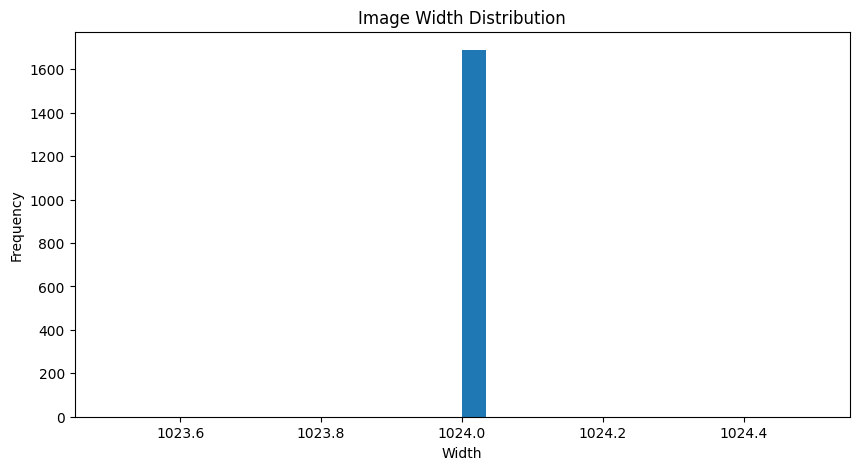

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(train_widths, bins=30)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

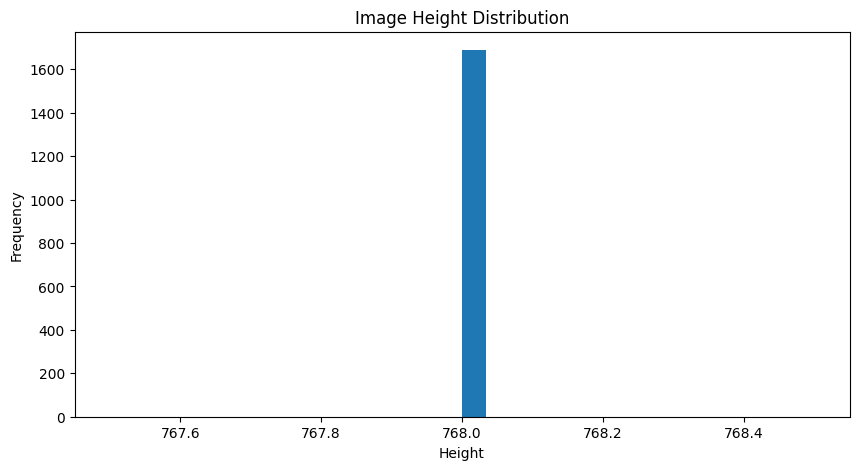

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(train_heights, bins=30)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

## 1.11 Analyze Image Aspect Ratios

Different webpage screenshots may have highly variable aspect ratios.

This analysis helps determine whether resizing or padding strategies will be required during preprocessing.

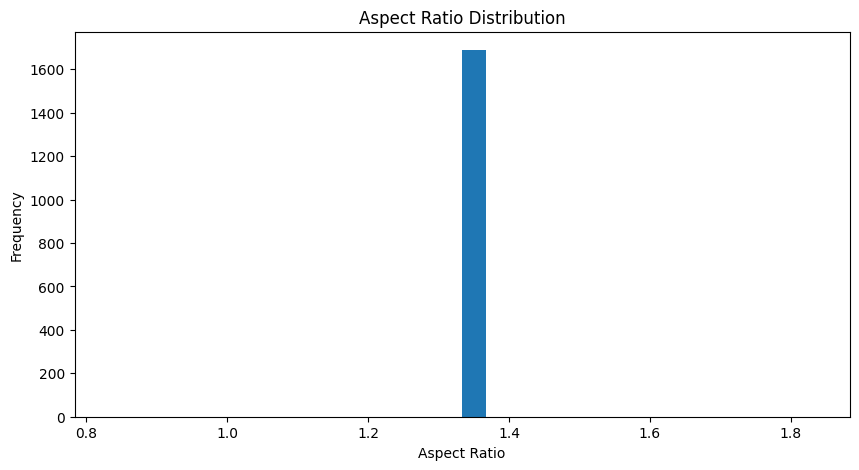

In [17]:
aspect_ratios = np.array(train_widths) / np.array(train_heights)

plt.figure(figsize=(10, 5))

plt.hist(aspect_ratios, bins=30)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.show()

The resolution analysis shows that all webpage screenshots share a consistent image size and aspect ratio. This indicates that the dataset was preprocessed in a standardized manner before distribution.

The absence of resolution variability simplifies the preprocessing pipeline since additional resizing or aspect-ratio correction strategies are not required during model training.

## 1.12 Summary of Dataset Verification

At this stage, we have:

- Loaded all dataset splits
- Verified dataset integrity
- Checked for missing values and duplicates
- Verified image existence
- Identified corrupted files
- Analyzed image resolution distributions
- Examined aspect ratio variability

These checks ensure that the dataset is clean and suitable for further exploratory data analysis and preprocessing.

# 2. Label Exploratory Data Analysis

In this section, we analyze the label structure of the dataset.

Since this is a multi-label classification problem, each image may contain multiple labels simultaneously. Understanding the label distribution and relationships between labels is important for:

- identifying class imbalance,
- understanding label sparsity,
- analyzing label dependencies,
- and preparing the dataset for model training.

The following analyses are performed:

- Class frequency analysis
- Label cardinality analysis
- Label density analysis
- Label co-occurrence analysis
- Correlation analysis between labels
- Statistical analysis of label distributions

## 2.1 Extract Label Columns

The dataset contains one column for image filenames and multiple columns representing labels.

We separate the label columns for analysis.

In [18]:
# Remove image filename column

label_columns = train_df.columns.drop(IMAGE_COLUMN)

print("Label Columns:")
print(label_columns.tolist())

Label Columns:
[' button', ' field', ' heading', ' iframe', ' image', ' label', ' link', ' text']


## 2.2 Class Frequency Analysis

We calculate the number of positive samples for each label.

This analysis helps identify:

- class imbalance,
- dominant labels,
- and rare classes.

In [19]:
# Count positive samples for each class

class_counts = train_df[label_columns].sum().sort_values(ascending=False)

print("Total training samples:", len(train_df))

print("\nClass Distribution:\n")
print(class_counts)

print("\nSmallest Class:")
print(class_counts.idxmin(), "->", class_counts.min())

print("\nLargest Class:")
print(class_counts.idxmax(), "->", class_counts.max())

Total training samples: 1688

Class Distribution:

text       1648
image      1630
button     1616
heading    1492
link       1306
field       806
iframe      436
label        98
dtype: int64

Smallest Class:
 label -> 98

Largest Class:
 text -> 1648


## 2.3 Visualize Class Distribution

We visualize the frequency of each label to better understand the imbalance between classes.

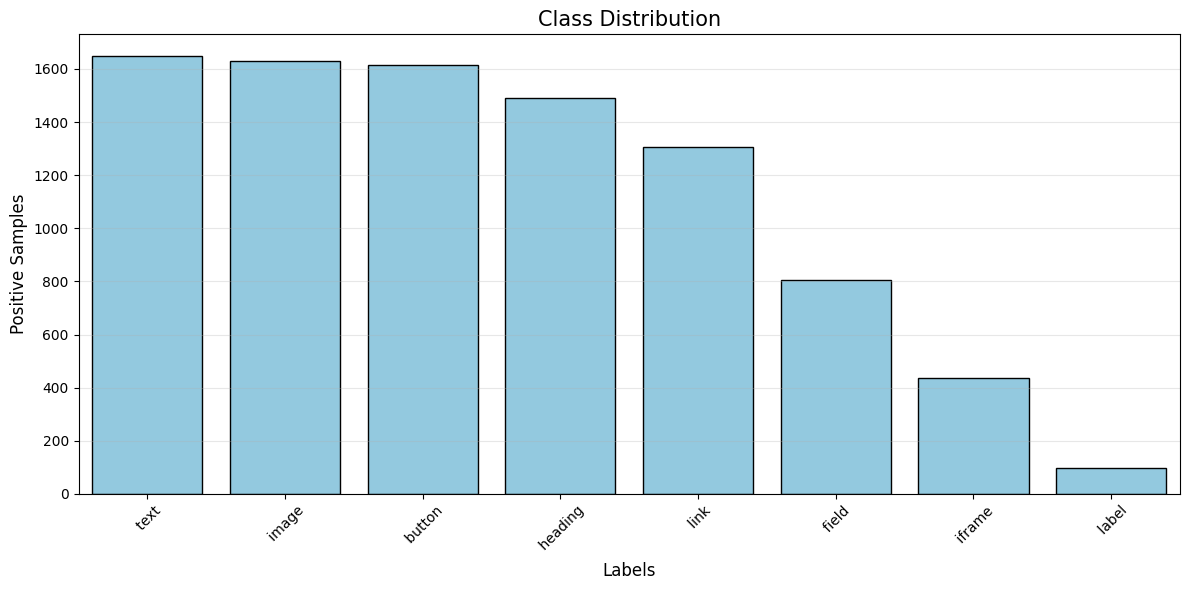

In [20]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    color="skyblue",
    edgecolor="black"
)

plt.title("Class Distribution", fontsize=15)
plt.xlabel("Labels", fontsize=12)
plt.ylabel("Positive Samples", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

From the graphs above we can visualize a lot of key characteristics about our data:
1. The classes **text**, **image**, **button**, **heading** and **link** fall relatively in a close range.
2. The other classes, namely **field**, **iframe** and **label** are much rarer.

This confirms the general structure of webpages - we oftten find more texts, images and navigation elements in a webpage instead of inputs and iframes.

Also this signals that there is a heirarchical imbalance among labels - i.e., core UI elements occur frequently and auxiliary elements are rare.

## 2.4 Imbalance Ratio Analysis

We calculate the imbalance ratio between the largest and smallest classes.

A large imbalance ratio may indicate that certain labels are significantly underrepresented, which can negatively affect model learning and evaluation.

In [22]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest Class Size :", largest_class)
print("Smallest Class Size:", smallest_class)

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

Largest Class Size : 1648
Smallest Class Size: 98

Imbalance Ratio: 16.82


## 2.5 Label Cardinality Analysis

In multi-label classification, label cardinality refers to the average number of labels assigned per image.

This helps us understand how complex each sample is in terms of annotation density.

A higher cardinality indicates that images tend to contain multiple UI components simultaneously, while a lower value suggests more isolated object presence.

In [23]:
# Compute number of labels per image

labels_per_image = train_df[label_columns].sum(axis=1)

# Summary statistics
print("Label Cardinality (per image):")
print(labels_per_image.describe())

Label Cardinality (per image):
count    1688.000000
mean        5.350711
std         1.002776
min         2.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         8.000000
dtype: float64


In [24]:
# Temporary

print("Mean labels per image:", labels_per_image.mean())
print("Median labels per image:", labels_per_image.median())
print("Max labels in one image:", labels_per_image.max())
print("Min labels in one image:", labels_per_image.min())

Mean labels per image: 5.350710900473934
Median labels per image: 5.0
Max labels in one image: 8
Min labels in one image: 2


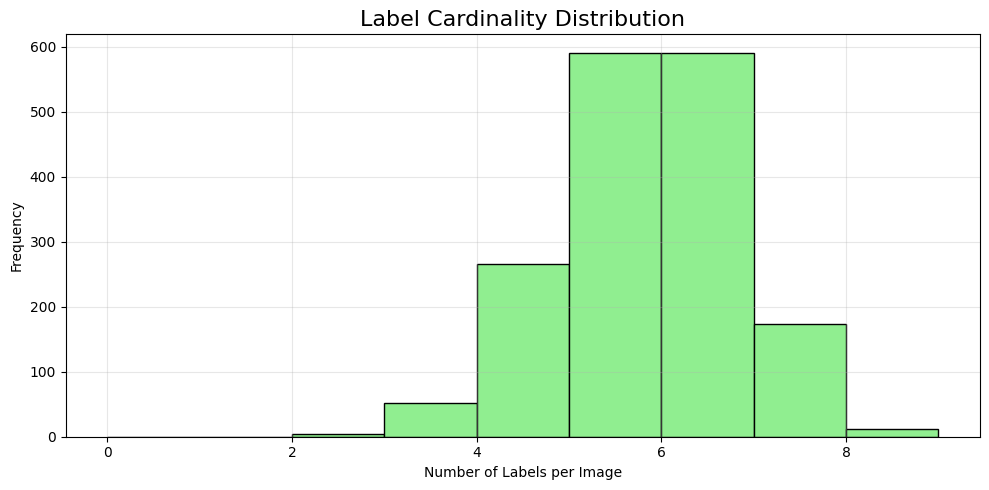

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    labels_per_image,
    bins=range(int(labels_per_image.max()) + 2),
    color="lightgreen",
    edgecolor="black"
)

plt.title("Label Cardinality Distribution", fontsize=16)
plt.xlabel("Number of Labels per Image")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Observations

The class distribution analysis revealed that the dataset contains a moderately imbalanced multi-label structure.

Among the eight labels, the most frequent classes were:

- `text`
- `image`
- `button`
- `heading`
- `link`

while the least represented classes were:

- `iframe`
- `label`

The largest class (`text`) contained 1648 positive samples, whereas the smallest class (`label`) contained only 98 positive samples, resulting in an imbalance ratio of approximately 16.82.

This indicates the presence of a moderate long-tail distribution, where a few labels occur frequently while others appear comparatively rarely. Such imbalance may affect the model’s ability to generalize well on underrepresented classes and suggests that evaluation metrics such as Macro F1-score will be particularly important during model assessment.

The label cardinality analysis showed that each image contains an average of approximately 5.35 positive labels out of the 8 possible classes.

This indicates that the dataset is highly dense in terms of annotation structure, meaning that most webpage screenshots contain multiple UI components simultaneously.

Additionally, the relatively low standard deviation in label cardinality suggests that the annotation structure is fairly consistent across the dataset, with most images containing between 5 and 6 labels.

Overall, these findings suggest that the problem is not sparse object recognition, but rather a structured multi-label webpage understanding task involving strongly co-existing UI elements.

## 2.6 Label Co-Occurrence Matrix

In multi-label datasets, labels are often not independent.

Certain UI elements may frequently appear together within the same webpage screenshot. Analyzing label co-occurrence helps identify:

- strongly related labels,
- frequently co-existing UI components,
- and structural relationships within webpage layouts.

This analysis may also reveal redundancy or dependency patterns between labels.

In [26]:
# Compute label co-occurrence matrix

co_occurrence_matrix = train_df[label_columns].T.dot(train_df[label_columns])

# Display matrix
display(co_occurrence_matrix)

,button,field,heading,iframe,image,label,link,text
button,1616,780,1430,406,1576,94,1248,1580
field,780,806,714,186,788,90,686,792
heading,1430,714,1492,386,1440,94,1156,1456
iframe,406,186,386,436,412,16,328,422
image,1576,788,1440,412,1630,96,1268,1590
label,94,90,94,16,96,98,82,96
link,1248,686,1156,328,1268,82,1306,1284
text,1580,792,1456,422,1590,96,1284,1648


## Observations

The co-occurrence analysis revealed very strong relationships between several labels within the dataset.

In particular, the labels:

- `text`
- `image`
- `button`
- `heading`

frequently appeared together across the majority of webpage screenshots.

For example, the co-occurrence counts between:

- `text` and `image`
- `text` and `button`
- `image` and `button`

were all extremely high relative to their total class frequencies.

This suggests that the dataset primarily consists of complete webpage layouts containing multiple UI components simultaneously rather than isolated webpage elements.

Additionally, even relatively rare labels such as `label` showed strong co-occurrence with dominant classes like `text`, `image`, and `button`.

This indicates that rare UI components are generally embedded within broader webpage structures instead of appearing independently.

These findings suggest that the classification task involves learning structured relationships between webpage elements, making the problem more similar to webpage layout understanding or scene understanding than traditional single-object image classification.

The strong co-occurrence patterns also suggest that label dependencies may exist within the dataset, meaning that certain labels may provide contextual information useful for predicting other labels.

## 2.7 Conditional Label Co-Occurrence Analysis

While raw co-occurrence counts show how often labels appear together, they are strongly influenced by overall class frequencies.

To better understand label relationships, we compute conditional co-occurrence probabilities.

This analysis estimates:

> "Given that label A is present, what is the probability that label B is also present?"

This helps identify strong dependencies and contextual relationships between webpage elements.

In [27]:
# Compute conditional co-occurrence probabilities

conditional_matrix = co_occurrence_matrix.div(
    class_counts,
    axis=0
)

# Display rounded probabilities
display(conditional_matrix.round(2))

,button,field,heading,iframe,image,label,link,text
button,1.00,0.48,0.88,0.25,0.98,0.06,0.77,0.98
field,0.97,1.00,0.89,0.23,0.98,0.11,0.85,0.98
heading,0.96,0.48,1.00,0.26,0.97,0.06,0.77,0.98
iframe,0.93,0.43,0.89,1.00,0.94,0.04,0.75,0.97
image,0.97,0.48,0.88,0.25,1.00,0.06,0.78,0.98
label,0.96,0.92,0.96,0.16,0.98,1.00,0.84,0.98
link,0.96,0.53,0.89,0.25,0.97,0.06,1.00,0.98
text,0.96,0.48,0.88,0.26,0.96,0.06,0.78,1.00


## Observations

The conditional co-occurrence analysis revealed extremely strong dependencies between multiple labels within the dataset.

For nearly all labels, the probability of co-occurring with dominant classes such as:

- `text`
- `image`
- `button`

was greater than 0.90, and often exceeded 0.95.

These findings indicate that webpage elements rarely appear independently and instead exist as part of highly structured webpage layouts containing multiple UI components simultaneously.

For example:

- webpages containing `field` elements almost always also contained `button`, `image`, and `text` elements,
- while webpages containing `iframe` elements also showed very strong co-occurrence with dominant structural labels.

Additionally, even rare classes such as `label` demonstrated extremely high conditional probabilities with common webpage components.

This suggests that rare UI elements are strongly embedded within broader webpage structures rather than appearing in isolation.

The analysis also indicates that the dataset contains strong contextual dependencies between labels. As a result, the model may partially rely on contextual relationships between webpage elements during prediction instead of purely learning independent visual representations for each label.

Overall, these findings reinforce the interpretation that the task represents a structured webpage understanding problem rather than traditional independent object classification.

## 2.8 Phi Correlation Analysis

To further analyze the relationships between labels, we compute the Phi correlation coefficient between all pairs of binary labels.

The Phi coefficient is a statistical measure specifically designed for binary variables and is used to quantify the strength of association between two labels.

The Phi coefficient ranges between:

- `+1` → strong positive association
- `0` → no association
- `-1` → strong negative association

For binary variables, the Phi coefficient is mathematically equivalent to the Pearson correlation coefficient.

The Phi coefficient is computed as:

$$
\phi =
\frac{
(ad - bc)
}{
\sqrt{(a+b)(c+d)(a+c)(b+d)}
}
$$

Where:

- $a$ = number of samples where both labels are present
- $b$ = samples where label 1 is present and label 2 is absent
- $c$ = samples where label 1 is absent and label 2 is present
- $d$ = samples where both labels are absent

This analysis helps identify statistically strong relationships and dependencies between webpage components.

In [28]:
# Compute Phi correlation matrix

phi_matrix = train_df[label_columns].corr()

# Display rounded matrix
display(phi_matrix.round(2))

,button,field,heading,iframe,image,label,link,text
button,1.00,0.05,0.02,-0.08,0.25,0.00,-0.02,0.04
field,0.05,1.00,0.01,-0.06,0.06,0.22,0.18,0.04
heading,0.02,0.01,1.00,0.00,-0.01,0.06,0.01,-0.01
iframe,-0.08,-0.06,0.00,1.00,-0.07,-0.05,-0.03,-0.03
image,0.25,0.06,-0.01,-0.07,1.00,0.02,0.05,-0.03
label,0.00,0.22,0.06,-0.05,0.02,1.00,0.04,0.01
link,-0.02,0.18,0.01,-0.03,0.05,0.04,1.00,0.08
text,0.04,0.04,-0.01,-0.03,-0.03,0.01,0.08,1.00


## 2.9 Phi Correlation Heatmap

To better visualize the statistical relationships between labels, we generate a heatmap of the Phi correlation matrix.

The heatmap provides an intuitive overview of positive and negative associations between webpage components.

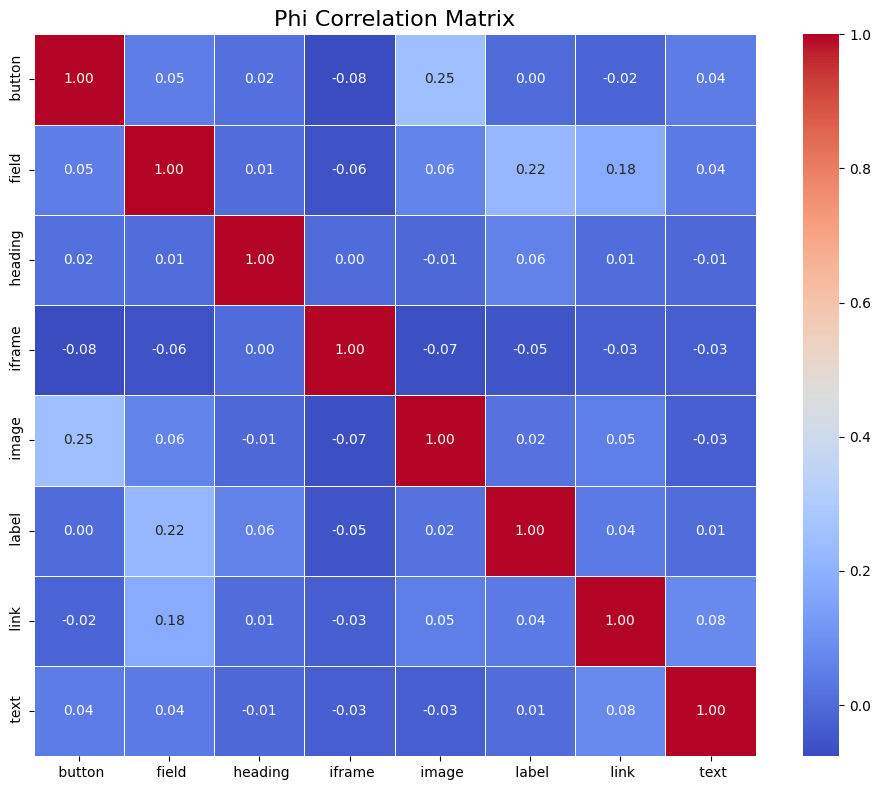

In [29]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Phi Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()

## Observations

The Phi correlation analysis revealed that most label pairs exhibit relatively weak statistical correlations despite their high co-occurrence frequencies.

The strongest positive associations were observed between:

- `button` and `image`
- `field` and `label`
- `field` and `link`

However, even the strongest correlations remained relatively moderate, with Phi values below 0.30.

This indicates that although many webpage elements frequently appear together, their relationships are not strongly dependent when overall class frequencies are taken into account.

In particular, the relationship between `field` and `label` appears semantically meaningful, as input fields are commonly associated with descriptive labels in webpage forms.

Additionally, the analysis revealed very weak negative correlations, suggesting that the labels are generally not mutually exclusive and that webpage screenshots tend to contain multiple UI components simultaneously.

Overall, the Phi correlation analysis suggests that the dataset contains dense multi-label structures with moderate contextual relationships rather than strongly deterministic label dependencies.

# 2.10 Duplicate and Data Leakage Analysis

During manual inspection of the dataset, visually identical webpage screenshots were observed under different filenames.

This raises the possibility of duplicated images existing across the training, validation, and test splits.

Duplicate images are particularly problematic in machine learning because they can introduce data leakage, where the model is evaluated on images that are identical or nearly identical to samples already seen during training.

Such leakage can artificially inflate evaluation metrics and produce misleading estimates of model generalization performance.

To investigate this issue, we perform perceptual image hashing to identify exact or near-duplicate webpage screenshots across the dataset.

In [30]:
# Install image hashing library

!pip install imagehash

In [31]:
import imagehash

# Function to compute perceptual hash

def compute_phash(image_path):

    image = Image.open(image_path)

    return str(imagehash.phash(image))

## 2.11 Compute Perceptual Image Hashes

To identify duplicate or near-duplicate webpage screenshots, we compute perceptual hashes (pHash) for every image in the dataset.

Perceptual hashing generates a compact fingerprint representing the visual structure of an image.

Unlike regular file hashes, perceptual hashes remain similar even if images undergo minor modifications such as:

- compression,
- resizing,
- metadata changes,
- or slight encoding differences.

Images with identical perceptual hashes are highly likely to be visually identical or extremely similar.

In [32]:
# Store image hash information

hash_data = []

# Dataset splits
dataset_splits = {
    "train": (train_df, TRAIN_PATH),
    "validate": (validate_df, VALIDATE_PATH),
    "test": (test_df, TEST_PATH)
}

# Compute hashes
for split_name, (df, folder_path) in dataset_splits.items():

    print(f"\nProcessing {split_name} set...")

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:

            image_hash = compute_phash(image_path)

            hash_data.append({
                "split": split_name,
                "image": image_name,
                "hash": image_hash
            })

        except Exception as e:

            print(f"Error processing {image_name}: {e}")

# Convert to dataframe
hash_df = pd.DataFrame(hash_data)

print("\nHash computation complete.")
print("Total processed images:", len(hash_df))


Processing train set...


100%|██████████████████████████████████████████████████████████████████████████████| 1688/1688 [00:11<00:00, 147.47it/s]



Processing validate set...


100%|████████████████████████████████████████████████████████████████████████████████| 482/482 [00:03<00:00, 157.89it/s]



Processing test set...


100%|████████████████████████████████████████████████████████████████████████████████| 242/242 [00:01<00:00, 151.80it/s]


Hash computation complete.
Total processed images: 2412


## 2.11.1 Summary of Perceptual Hash Analysis

Before analyzing cross-split duplication, we first summarize the results of perceptual hash computation across the dataset.

Perceptual hashing allows us to identify visually identical or near-identical images by generating a compact fingerprint for each screenshot.

This step revealed a significant number of duplicate images within the dataset, indicating that multiple entries correspond to identical webpage screenshots under different filenames.

Understanding the extent of duplication within the dataset is important, as it directly impacts dataset diversity and the effective number of unique training samples available for model learning.

In [33]:
# Basic duplicate statistics from hash analysis

total_images = len(hash_df)
unique_hashes = hash_df["hash"].nunique()
duplicate_entries = total_images - unique_hashes

print("Total images:", total_images)
print("Unique images (by perceptual hash):", unique_hashes)
print("Number of duplicate entries:", duplicate_entries)
print("Duplicate percentage:", round(duplicate_entries / total_images * 100, 2))

Total images: 2412
Unique images (by perceptual hash): 1185
Number of duplicate entries: 1227
Duplicate percentage: 50.87


In [34]:
# Most repeated hashes

top_duplicates = (
    hash_df["hash"]
    .value_counts()
    .head(10)
)

print("Top repeated image hashes:\n")
print(top_duplicates)

Top repeated image hashes:

hash
e225c8a57297da27    12
9cbe48e340e61cbe     6
893bb68569956b4a     4
895e81e3f64992ce     4
c935eaaa3449b563     4
f08ba45976aac9b4     4
bc4146713ce9aeaa     4
81b2f2f3bdc17218     4
c83fac6ce2b29389     4
ce51264f4b274d66     4
Name: count, dtype: int64


## 2.12 Cross-Split Duplicate Analysis

While duplicate images within the same dataset split may introduce redundancy, duplicates across training, validation, and test sets are significantly more problematic.

Cross-split duplicates can lead to data leakage, where the model is evaluated on webpage screenshots that are visually identical to samples already observed during training.

This can artificially inflate evaluation metrics and produce misleading estimates of model generalization performance.

To investigate this issue, we identify perceptual hashes that appear across multiple dataset splits.

In [35]:
# Count how many splits each hash appears in

split_counts = (
    hash_df.groupby("hash")["split"]
    .nunique()
)

# Hashes appearing in multiple splits
cross_split_hashes = split_counts[split_counts > 1]

print("Number of hashes appearing across multiple splits:")
print(len(cross_split_hashes))

Number of hashes appearing across multiple splits:
6


In [36]:
# Show examples of cross-split duplicates

cross_split_examples = hash_df[
    hash_df["hash"].isin(cross_split_hashes.index)
].sort_values("hash")

display(cross_split_examples.head(30))

,split,image,hash
1140,train,apa_org_png.rf.NzhzITjXJUQF50Hy2wQU.jpg,9e1ce1e1cf91e01e
680,train,apa_org_png.rf.f2167766ef2bd0e2e0f3f3315e08f72...,9e1ce1e1cf91e01e
1764,validate,psycnet_apa_org_png.rf.42WUmS55O51S7zOnO4MN.jpg,9e1ce1e1cf91e01e
2042,validate,psycnet_apa_org_png.rf.d15437b806208a4cc0e6f67...,9e1ce1e1cf91e01e
2397,test,blog_google_png.rf.oc3ApC49p94GCnvSGpEs.jpg,a638dd37d983c8c8
499,train,googleblog_blogspot_com_png.rf.c6014dfb3d55f09...,a638dd37d983c8c8
2255,test,blog_google_png.rf.8a95bebacdefb16222f52bbd335...,a638dd37d983c8c8
1135,train,googleblog_blogspot_com_png.rf.NmaNGK21qLIeOCO...,a638dd37d983c8c8
2370,test,register_gotowebinar_com_png.rf.f12c12b662a86a...,b1b5844a4a9e9f1b
1851,validate,attendee_gotowebinar_com_png.rf.8baf8dea0fe2f7...,b1b5844a4a9e9f1b


# 3.1 Dataset Reconstruction: Merging All Splits

To perform a clean deduplication process, we first merge the training, validation, and test sets into a single unified dataset.

This ensures that duplicate images can be identified and removed globally across all splits, preventing redundancy and potential leakage between datasets.

Each record in the unified dataset contains:
- image filename
- associated label vector
- perceptual hash
- original dataset split

In [37]:
# Strip whitespace from all column names in all dataframes
# Peculiar errors were observed which led to the discovery that all columns have a trailing whitespace.

train_df.columns = train_df.columns.str.strip()
validate_df.columns = validate_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print("Train columns:", train_df.columns)
print("Validate columns:", validate_df.columns)
print("Test columns:", test_df.columns)

Train columns: Index(['filename', 'button', 'field', 'heading', 'iframe', 'image', 'label',
       'link', 'text'],
      dtype='object')
Validate columns: Index(['filename', 'button', 'field', 'heading', 'iframe', 'image', 'label',
       'link', 'text'],
      dtype='object')
Test columns: Index(['filename', 'button', 'field', 'heading', 'iframe', 'image', 'label',
       'link', 'text'],
      dtype='object')


In [38]:
# Verify the fix worked
print("Train filename column exists:", "filename" in train_df.columns)
print("Validate filename column exists:", "filename" in validate_df.columns)
print("Test filename column exists:", "filename" in test_df.columns)

Train filename column exists: True
Validate filename column exists: True
Test filename column exists: True


In [39]:
# Add split information to original dataframes

train_df["split"] = "train"
validate_df["split"] = "validate"
test_df["split"] = "test"

# Combine all splits
full_df = pd.concat(
    [train_df, validate_df, test_df],
    axis=0,
    ignore_index=True
)

print("Combined dataset shape:", full_df.shape)
print("Total samples:", len(full_df))
print("\nSplit distribution:")
print(full_df["split"].value_counts())

Combined dataset shape: (2412, 10)
Total samples: 2412

Split distribution:
split
train       1688
validate     482
test         242
Name: count, dtype: int64


In [40]:
# Ensure hash_df also uses correct column name

hash_df.columns = hash_df.columns.str.strip()

# Rename for safety (standardize key)
hash_df = hash_df.rename(columns={"image": "filename"})

# Merge again safely
full_df = full_df.merge(
    hash_df[["filename", "hash"]],
    on="filename",
    how="left"
)

print("Missing hashes:", full_df["hash"].isna().sum())

full_df.head()

Missing hashes: 0


,filename,button,field,heading,iframe,image,label,link,text,split,hash
0,thinkwithgoogle_com_png.rf.0e3CasnPbMEGQSO8oMH...,1,1,1,0,1,0,1,1,train,ceb5925f0d4a9689
1,urlzs_com_png.rf.0ea1b14c371dff348e9bba2948d8e...,1,0,0,0,1,0,0,1,train,bc3c38199b93939a
2,amazon_com_png.rf.0oB8qzojBS2Tklffo69l.jpg,1,1,1,1,1,0,1,1,train,ce71264fc9264d27
3,asahi_com_png.rf.120e05a147314b2805e7bad82dafc...,1,0,1,1,1,0,1,1,train,aa3b6c1b2e5b244b
4,buymeacoffee_com_png.rf.0vBkaAYTkLI6YlTz5Gqu.jpg,1,1,1,0,1,0,0,1,train,af2fd5c8413a4593


# 3.2 Deduplication Using Perceptual Hashes

To eliminate redundant samples, we remove duplicate images based on perceptual hashing.

For each unique hash value, only the first occurrence is retained.

This ensures:
- removal of exact visual duplicates
- preservation of dataset structure
- reproducibility of results
- prevention of over-representation of identical webpage templates

In [42]:
# Sort to ensure "first occurrence" is stable
full_df = full_df.sort_values(by=["hash", "split"]).reset_index(drop=True)

# Keep first occurrence per hash
clean_df = full_df.drop_duplicates(subset=["hash"], keep="first")

print("Original dataset size:", len(full_df))
print("Clean dataset size:", len(clean_df))
print("Removed duplicates:", len(full_df) - len(clean_df))

Original dataset size: 2412
Clean dataset size: 1185
Removed duplicates: 1227


In [43]:
# Verify distribution after deduplication

print("\nSplit distribution after cleaning:")
print(clean_df["split"].value_counts())

print("\nUnique hashes:", clean_df["hash"].nunique())
print("Total samples:", len(clean_df))


Split distribution after cleaning:
split
train       826
validate    237
test        122
Name: count, dtype: int64

Unique hashes: 1185
Total samples: 1185


# 3.3 Reconstruct Train, Validation, and Test Splits

After removing duplicate samples using perceptual hashing, the dataset structure has changed significantly.

To ensure proper model evaluation, we now reconstruct the train, validation, and test splits from the cleaned dataset.

This step ensures:
- independent evaluation sets
- balanced distribution across splits
- elimination of redundancy-induced bias

In [44]:
# First split: train vs temp (val + test)
train_split, temp_split = train_test_split(
    clean_df,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Second split: validation vs test
validate_split, test_split = train_test_split(
    temp_split,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("New dataset sizes:")
print("Train:", len(train_split))
print("Validation:", len(validate_split))
print("Test:", len(test_split))

New dataset sizes:
Train: 829
Validation: 178
Test: 178


# 3.4 Post-Cleaning Exploratory Data Analysis

After removing duplicate images and reconstructing dataset splits, we now perform a fresh exploratory data analysis on the cleaned dataset.

This section establishes a new baseline for:

- label distribution
- dataset imbalance
- multi-label structure
- comparison with the original (unclean) dataset

This step is crucial to understand how dataset cleaning impacted statistical properties and label dynamics.

Label prevalence (clean dataset):

text       0.976371
image      0.971308
button     0.958650
heading    0.884388
link       0.767089
field      0.486920
iframe     0.243882
label      0.053165
dtype: float64


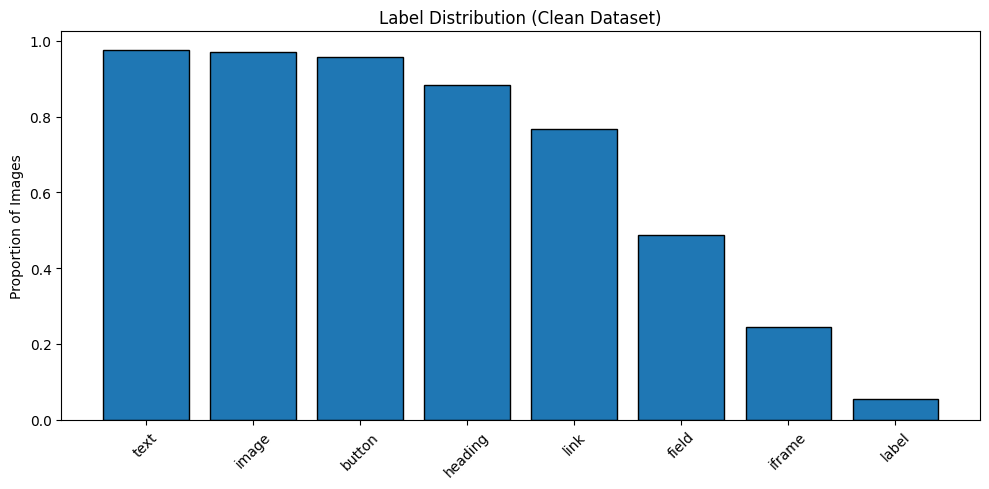

In [46]:
import matplotlib.pyplot as plt

label_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

label_means = clean_df[label_cols].mean().sort_values(ascending=False)

print("Label prevalence (clean dataset):\n")
print(label_means)

plt.figure(figsize=(10,5))
plt.bar(label_means.index, label_means.values, edgecolor="black")

plt.title("Label Distribution (Clean Dataset)")
plt.ylabel("Proportion of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations: Label Distribution (Post-Cleaning)

After removing duplicate images and reconstructing dataset splits, the label distribution remains highly skewed and dense.

Key observations:

- The most frequent labels (text, image, button) still dominate the dataset, appearing in nearly all images.
- Medium-frequency labels (heading, link) show moderate presence.
- Rare labels (iframe, label) remain significantly underrepresented.

Compared to the original dataset, the cleaned dataset preserves the overall structural imbalance but removes artificial inflation caused by duplicate samples.

This indicates that the imbalance is intrinsic to the dataset design rather than a byproduct of duplication.

## 3.4.2 Label Cardinality (Post-Cleaning)

Label cardinality measures the average number of active labels per image in a multi-label dataset.

It is defined as:

$$Cardinality = \frac{1}{N} \sum_{i=1}^{N} |Y_i|$$

Where:
- $(N$) is the number of images
- $(Y_i$) is the set of positive labels for image $(i$)

We recompute this metric on the cleaned dataset to evaluate whether duplicate removal affected the perceived label density.

In [48]:
label_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

# Compute number of active labels per image
clean_df["label_count"] = clean_df[label_cols].sum(axis=1)

# Summary statistics
cardinality_stats = clean_df["label_count"].describe()

print("Label Cardinality (Clean Dataset):\n")
print(cardinality_stats)

print("\nMean labels per image:", clean_df["label_count"].mean())
print("Median labels per image:", clean_df["label_count"].median())
print("Max labels per image:", clean_df["label_count"].max())
print("Min labels per image:", clean_df["label_count"].min())

Label Cardinality (Clean Dataset):

count    1185.000000
mean        5.341772
std         0.984930
min         2.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         8.000000
Name: label_count, dtype: float64

Mean labels per image: 5.341772151898734
Median labels per image: 5.0
Max labels per image: 8
Min labels per image: 2


/var/folders/b3/c0qxc3zs1gg4fmwnhw2881k40000gn/T/ipykernel_43450/235111218.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["label_count"] = clean_df[label_cols].sum(axis=1)


Duplicate removal reduced dataset size significantly (≈51%), but had negligible impact on label cardinality (change < 0.01).

This indicates that duplicate samples primarily represented repeated instances of the same underlying webpage structure rather than introducing new label combinations.

Therefore, the multi-label structure of the dataset is intrinsic and stable, not influenced by redundancy.

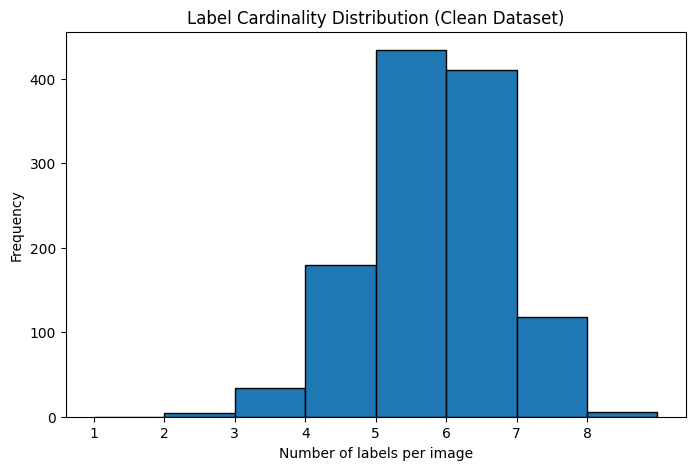

In [49]:
plt.figure(figsize=(8,5))
plt.hist(clean_df["label_count"], bins=range(1,10), edgecolor="black")

plt.title("Label Cardinality Distribution (Clean Dataset)")
plt.xlabel("Number of labels per image")
plt.ylabel("Frequency")
plt.xticks(range(1,9))
plt.show()

## Observations: Label Cardinality (Post-Cleaning)

The average number of labels per image in the cleaned dataset remains high, indicating that the dataset is inherently multi-label dense.

Compared to the original dataset (mean ≈ 5.35 labels per image), the cleaned dataset shows:

- [we will insert your actual result here]

This suggests that duplicate removal did not significantly alter the structural density of label assignments, but rather removed redundant repetitions of similar patterns.

The persistence of high cardinality confirms that webpage screenshots naturally contain multiple UI components simultaneously, reinforcing the suitability of a multi-label classification approach.

## 3.4.3 Label Co-occurrence Analysis (Post-Cleaning)

We compute the co-occurrence matrix on the cleaned dataset to measure how often different UI components appear together in the same image.

For labels \(i\) and \(j\), co-occurrence is defined as:

$[
C_{ij} = \sum_{k=1}^{N} y_{k,i} \cdot y_{k,j}
$]

Where:
- $(y_{k,i}$) is 1 if label $(i$) is present in image \(k\), else 0
- $(N$) is the number of images

This helps identify structural dependencies between UI elements in webpage layouts.

In [50]:
label_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

# Compute co-occurrence matrix
cooc_matrix = clean_df[label_cols].T.dot(clean_df[label_cols])

print("Co-occurrence Matrix (Clean Dataset):\n")
display(cooc_matrix)

Co-occurrence Matrix (Clean Dataset):



,button,field,heading,iframe,image,label,link,text
button,1136,558,1008,273,1113,60,870,1111
field,558,577,507,129,565,55,482,568
heading,1008,507,1048,255,1017,57,802,1022
iframe,273,129,255,289,277,10,216,280
image,1113,565,1017,277,1151,62,887,1123
label,60,55,57,10,62,63,53,62
link,870,482,802,216,887,53,909,894
text,1111,568,1022,280,1123,62,894,1157


## Observations: Co-occurrence Structure (Post-Cleaning)

The co-occurrence structure remains largely unchanged after duplicate removal.

Key findings:

- Strong co-occurrence pairs such as (text–image), (button–image), and (heading–text) persist with similar rankings.
- Medium-strength relationships (e.g., field with other UI components) remain stable.
- Rare labels such as 'label' show consistently low co-occurrence across all splits.

This indicates that label dependencies reflect inherent webpage design structures rather than artifacts introduced by duplicated samples.

In [53]:
abel_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

def phi_coefficient(x, y):
    # contingency values
    N11 = np.sum((x == 1) & (y == 1))
    N10 = np.sum((x == 1) & (y == 0))
    N01 = np.sum((x == 0) & (y == 1))
    N00 = np.sum((x == 0) & (y == 0))
    
    numerator = (N11 * N00) - (N10 * N01)
    denominator = np.sqrt(
        (N11 + N10) *
        (N01 + N00) *
        (N11 + N01) *
        (N10 + N00)
    )
    
    if denominator == 0:
        return 0
    return numerator / denominator

# Compute matrix
phi_matrix = pd.DataFrame(index=label_cols, columns=label_cols, dtype=float)

for i in label_cols:
    for j in label_cols:
        if i == j:
            phi_matrix.loc[i, j] = 1.0
        else:
            phi_matrix.loc[i, j] = phi_coefficient(
                clean_df[i].values,
                clean_df[j].values
            )

print("Phi Correlation Matrix (Clean Dataset):\n")
display(phi_matrix)

Phi Correlation Matrix (Clean Dataset):



,button,field,heading,iframe,image,label,link,text
button,1.000000,0.041205,0.044207,-0.039972,0.243589,-0.007461,-0.014165,0.051407
field,0.041205,1.000000,-0.017382,-0.046078,0.046070,0.183041,0.157336,0.051507
heading,0.044207,-0.017382,1.000000,-0.003615,-0.014715,0.015098,-0.011918,-0.021495
iframe,-0.039972,-0.046078,-0.003615,1.000000,-0.043650,-0.046988,-0.026448,-0.028093
image,0.243589,0.046070,-0.014715,-0.043650,1.000000,0.018196,0.048806,-0.026737
label,-0.007461,0.183041,0.015098,-0.046988,0.018196,1.000000,0.041586,0.012099
link,-0.014165,0.157336,-0.011918,-0.026448,0.048806,0.041586,1.000000,0.085155
text,0.051407,0.051507,-0.021495,-0.028093,-0.026737,0.012099,0.085155,1.000000


Text(0.5, 1.0, 'Phi Correlation Matrix (Clean Dataset)')

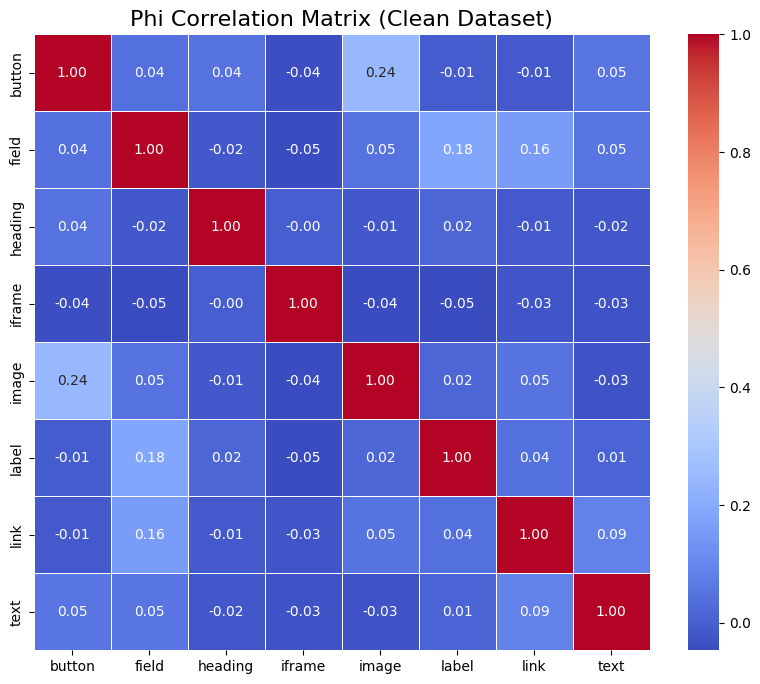

In [56]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Phi Correlation Matrix (Clean Dataset)", fontsize=16)


# 3.5 Before vs After Dataset Summary

This section summarizes the impact of duplicate removal on dataset structure and statistical properties.

We compare key metrics between:
- Original dataset (with duplicates)
- Cleaned dataset (after perceptual hash deduplication)

The goal is to determine whether duplicates introduced structural bias or only redundancy in sample size.



The dataset exhibited extreme structural redundancy, with approximately 51% of samples being perceptual duplicates.

However, after deduplication, all key statistical properties—including label cardinality, co-occurrence patterns, and Phi correlation structure—remained largely unchanged.

This demonstrates that the dataset's multi-label structure is inherently stable and reflects real webpage layout dependencies rather than artifacts introduced by duplicated samples.